In [223]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay

In [5]:
#Load the dataset
df = pd.read_csv(r"D:\Heart_disease_cleveland_new.csv")

In [7]:
#Display the first five rows
print("First 5 rows of the datatset: ")
print(df.head())

First 5 rows of the datatset: 
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   2     3       1  
3   0     1       0  
4   0     1       0  


In [9]:
#Display the information about the dataset
print("Information about the dataset: ")
print(df.info())

Information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [11]:
print("Missing values represented by '?'")
missing_values = df.isin(['?']).sum()
print(missing_values)

Missing values represented by '?'
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [13]:
X = df.drop('target',axis = 1) #Contains all the features in the X variable except for target feature 
y = df["target"] #This predicts whether there is presence or absence of heart disease 


In [15]:
categorical_features = ['sex', 'cp','fbs','restecg', 'exang','slope', 'ca','thal' ]
X_encoded = pd.get_dummies(X, columns = categorical_features, drop_first = True) #Converting into one hot encoded

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y) #stratify is  crucial for classification problems It ensures the proportion of classes

In [19]:
models = {"Logistic Regression": LogisticRegression(random_state = 42, solver = "liblinear"),
          "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")}

In [21]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train) #Training the model

    y_pred = model.predict(X_test)#Predict

    #Evaluate
    acc = accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred)
    rec = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    # Save results
    results[name] = {
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(f1, 3)
    }

# Display results
results_df = pd.DataFrame(results).T #for converting into a table
print("\nModel Performance Comparison:")
print(results_df)


D:\Anaconda\envs\heart_env\lib\site-packages\xgboost\training.py:183: UserWarning: [16:05:16] WARNING: D:\bld\xgboost-split_1755048450370\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Performance Comparison:
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.869      0.833   0.893     0.862
Random Forest           0.869      0.833   0.893     0.862
XGBoost                 0.852      0.828   0.857     0.842


In [23]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [25]:
# Initialize and train the models
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


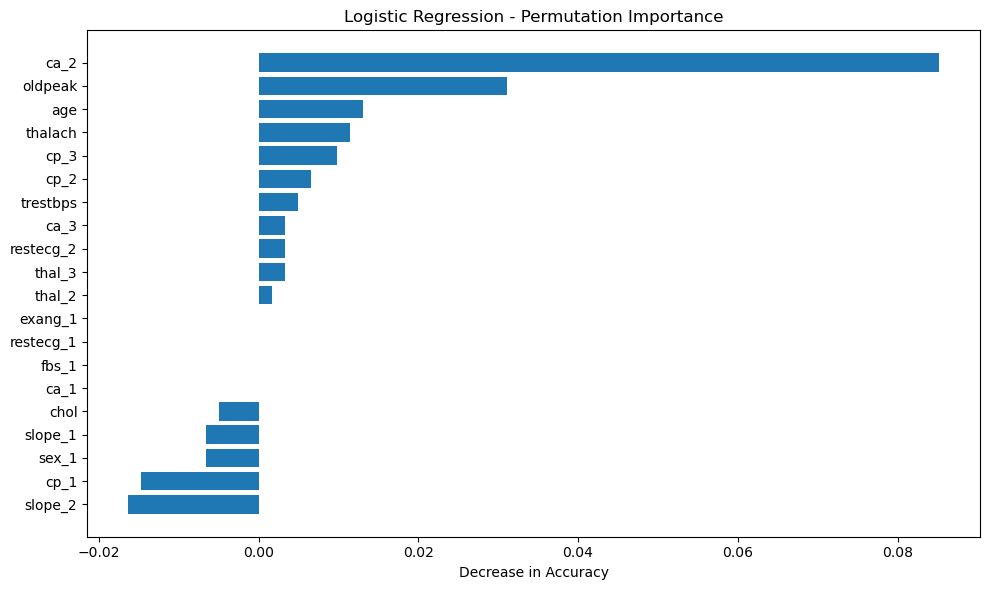

In [41]:
# --- Permutation Importance ---
# Logistic Regression
result_lr = permutation_importance(log_reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx_lr = result_lr.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx_lr], result_lr.importances_mean[sorted_idx_lr])
plt.title("Logistic Regression - Permutation Importance")
plt.xlabel("Decrease in Accuracy")
plt.tight_layout()
plt.show()

#A positive value means if the fetaure value increases than the probability of the outcome also increases
#A negative value means as the feature value increases the probabilty of the outcome also decreases

In [42]:
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


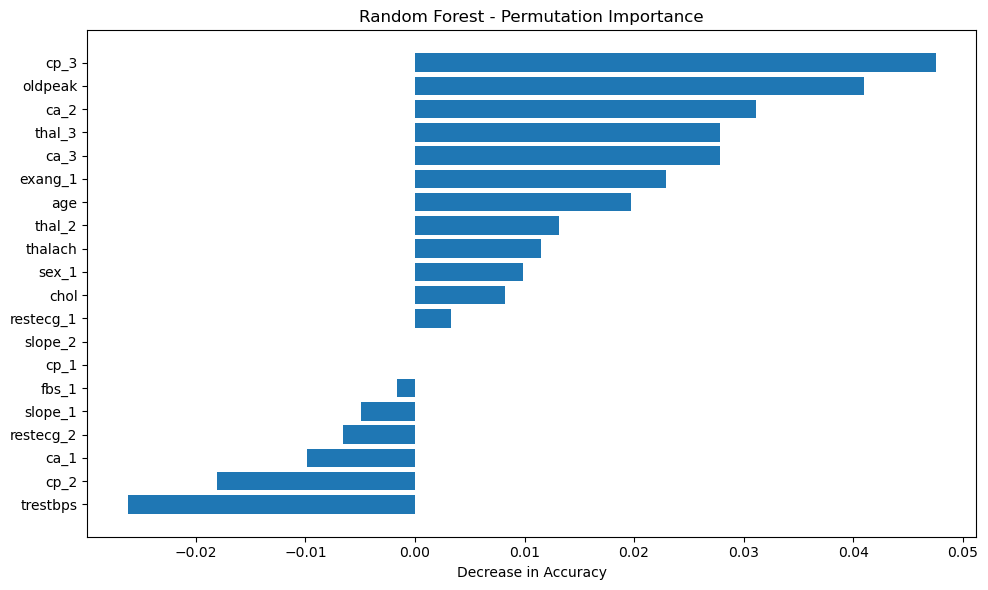

In [43]:
# Random Forest
result_rf = permutation_importance(random_forest, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx_rf = result_rf.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx_rf], result_rf.importances_mean[sorted_idx_rf])
plt.title("Random Forest - Permutation Importance")
plt.xlabel("Decrease in Accuracy")
plt.tight_layout()
plt.show()

In [44]:
XGBoost = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
XGBoost.fit(X_train, y_train)

D:\Anaconda\envs\heart_env\lib\site-packages\xgboost\training.py:183: UserWarning: [16:47:26] WARNING: D:\bld\xgboost-split_1755048450370\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


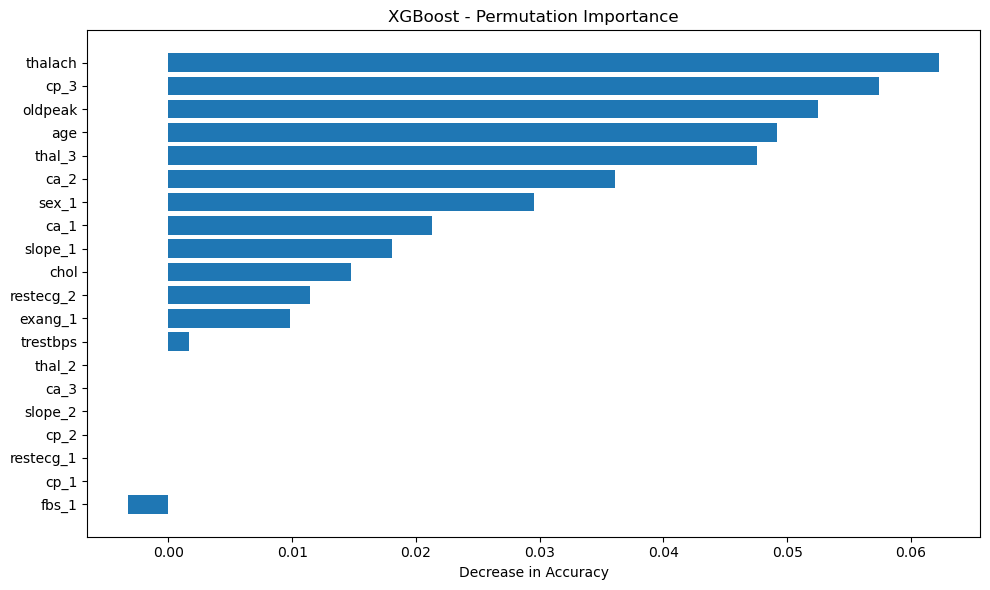

In [49]:
# Random Forest
result_xgboost = permutation_importance(XGBoost, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx_xgboost = result_xgboost .importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx_xgboost], result_xgboost.importances_mean[sorted_idx_xgboost])
plt.title("XGBoost - Permutation Importance")
plt.xlabel("Decrease in Accuracy")
plt.tight_layout()
plt.show()

D:\Anaconda\envs\heart_env\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
D:\Anaconda\envs\heart_env\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


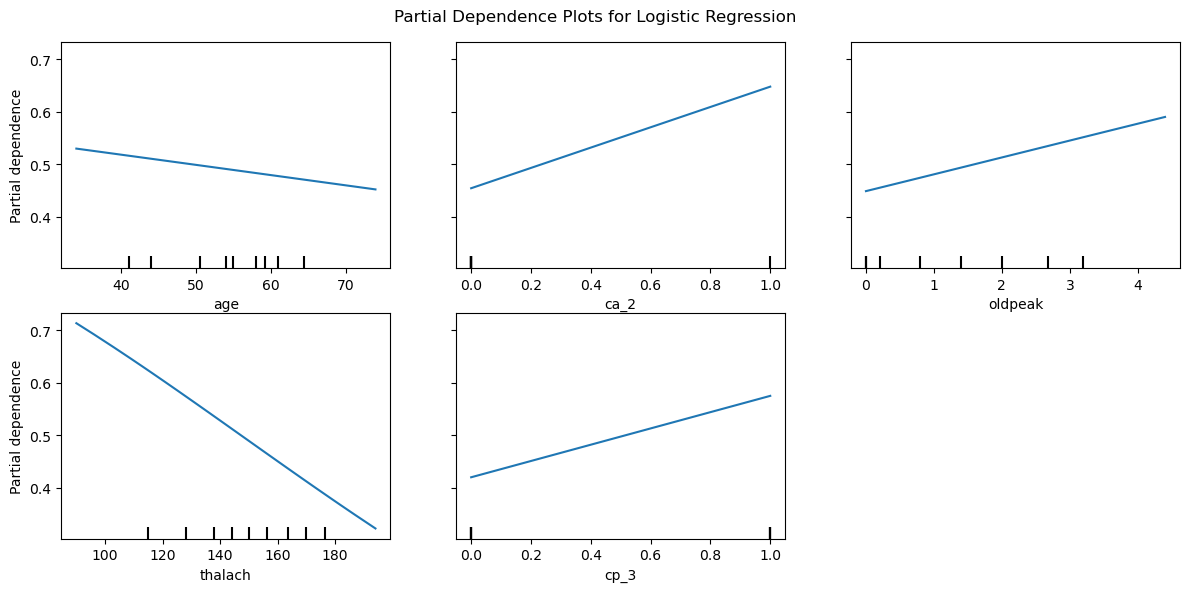

In [53]:
# --- Partial Dependence Plots (PDPs) ---
# PDPs for Logistic Regression
fig_lr, ax_lr = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(log_reg, X_test, features=['age', 'ca_2','oldpeak','thalach','cp_3'], ax=ax_lr)
fig_lr.suptitle('Partial Dependence Plots for Logistic Regression')
plt.tight_layout()
plt.show()


D:\Anaconda\envs\heart_env\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


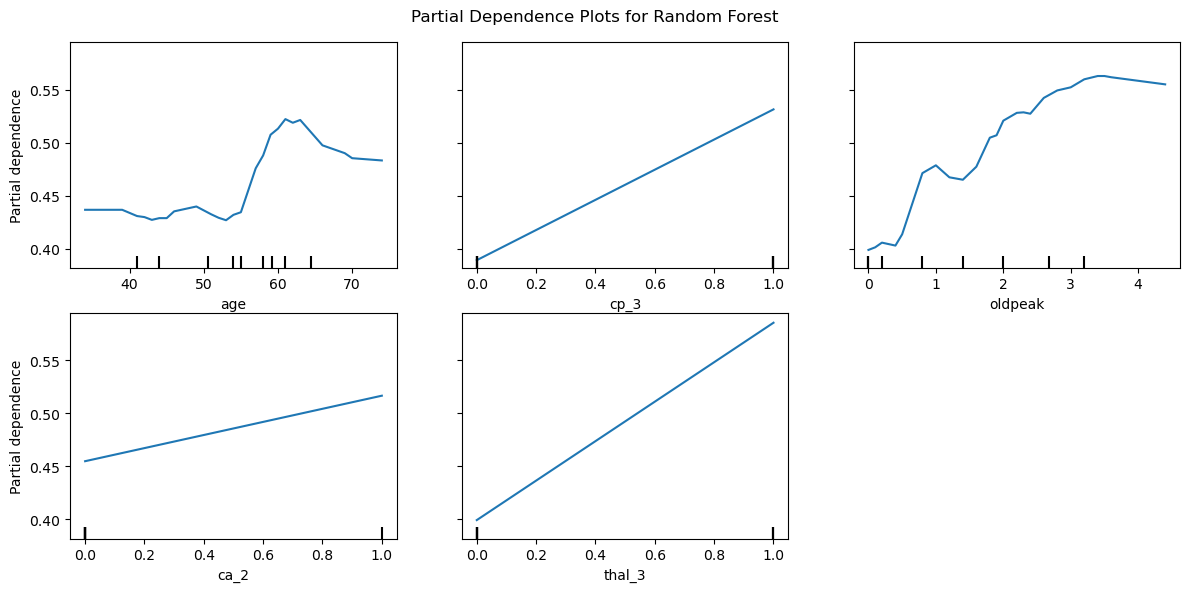

In [57]:

# PDPs for Random Forest
fig_rf, ax_rf = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(random_forest, X_test, features=['age','cp_3','oldpeak','ca_2','thal_3'], ax=ax_rf)
fig_rf.suptitle('Partial Dependence Plots for Random Forest')
plt.tight_layout()
plt.show()

D:\Anaconda\envs\heart_env\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


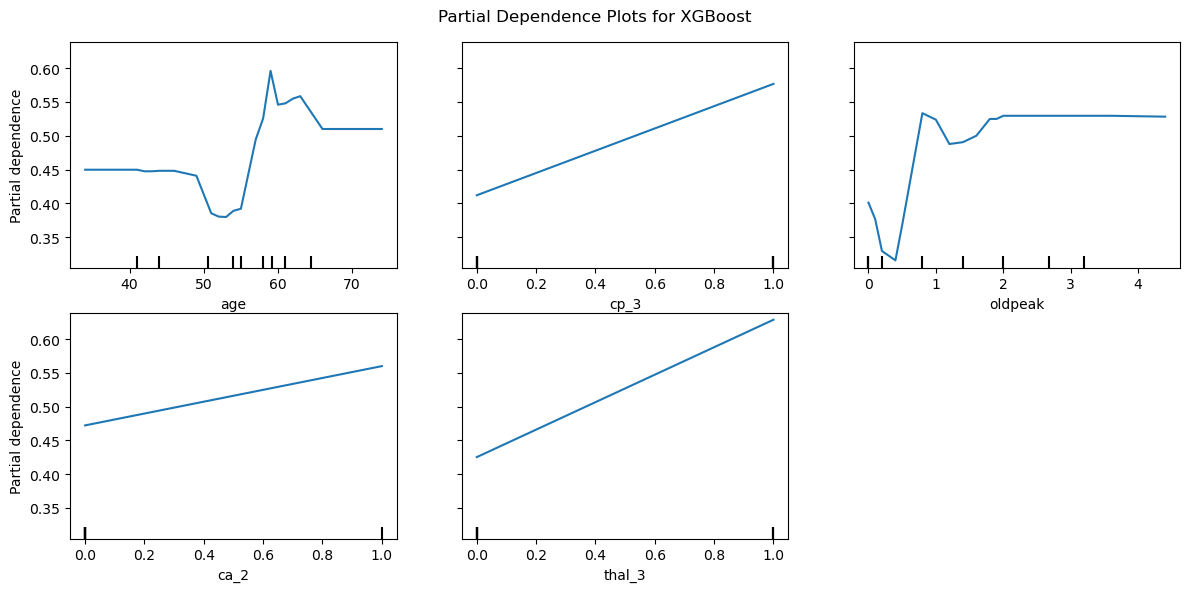

In [59]:
fig_rf, ax_rf = plt.subplots(figsize = (12,6))
PartialDependenceDisplay.from_estimator(XGBoost,X_test,features = ['age','cp_3','oldpeak','ca_2','thal_3'],ax = ax_rf) 
fig_rf.suptitle('Partial Dependence Plots for XGBoost')

plt.tight_layout()

plt.show()

In [184]:
import shap

In [201]:

masker = shap.maskers.Independent(X_train)
explainer = shap.LinearExplainer(log_reg, masker=masker)

shap_values = explainer.shap_values(X_test)  # shape: (samples, features)

shap.initjs()

# Use scalar expected_value (do NOT wrap in list) and single sample shap values
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0, :])


In [217]:
import shap

# Ensure train and test have the same columns and order
X_test = X_test[X_train.columns]

# Use numpy arrays for KernelExplainer
background = shap.sample(X_train, 100).values
explainer = shap.KernelExplainer(log_reg.predict_proba, background)

# Compute SHAP values on test set as numpy array
shap_values = explainer.shap_values(X_test.values, nsamples=100)

# Drop bias column from class 1 shap values
shap_values_class1 = shap_values[1][:, :-1]

# Plot SHAP summary plot with feature names
shap.summary_plot(shap_values_class1, features=X_test.values, feature_names=X_test.columns)


  0%|          | 0/61 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [205]:
import shap

# Single sample as 2D DataFrame
patient_to_explain = X_test.iloc[[0], :]

# Create explainer
explainer = shap.TreeExplainer(random_forest)

# Calculate shap values
shap_values_single = explainer.shap_values(patient_to_explain)  # shape (1, 20, 2)

# Extract SHAP values for class 1 of the first (only) sample
shap_vals_for_patient = shap_values_single[0, :, 1]  # shape (20,)

# Extract expected value for class 1
expected_value = explainer.expected_value[1]  # scalar

# Feature values as Series
features = patient_to_explain.iloc[0, :]

# Initialize JS visualization
shap.initjs()

# Plot SHAP force plot
shap.force_plot(expected_value, shap_vals_for_patient, features)


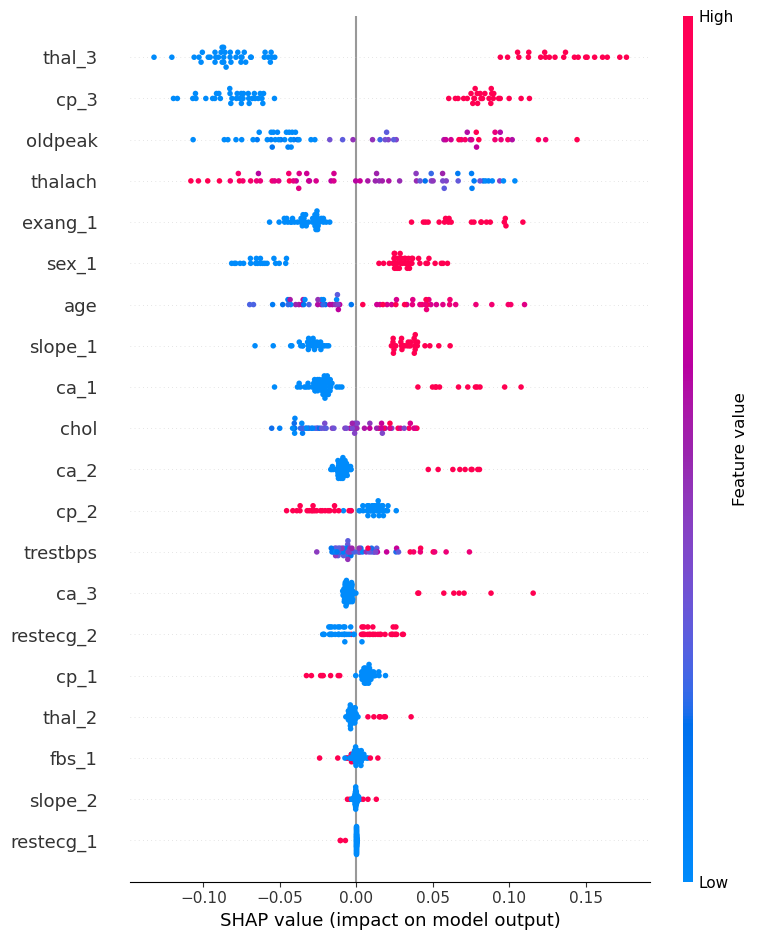

In [207]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(random_forest)

# Calculate SHAP values for whole test set, shape (n_samples, n_features, 2)
shap_values = explainer.shap_values(X_test)

# Extract SHAP values for positive class (class 1), shape (n_samples, n_features)
shap_values_pos_class = shap_values[:, :, 1]

# Generate SHAP summary plot
shap.summary_plot(shap_values_pos_class, X_test)



In [209]:
# Select single sample as 2D DataFrame
patient_to_explain = X_test.iloc[[0], :]

# Create SHAP explainer
explainer = shap.TreeExplainer(XGBoost)

# Calculate SHAP values (this returns 2D array, shape: samples x features)
shap_values_single = explainer.shap_values(patient_to_explain)

# Extract SHAP values for the first (only) sample
shap_vals_for_patient = shap_values_single[0]  # 1D array

# Extract expected value (scalar)
expected_value = explainer.expected_value

# Features as Series
features = patient_to_explain.iloc[0, :]

# Initialize JS visualization
shap.initjs()

# Generate force plot
shap.force_plot(expected_value, shap_vals_for_patient, features)

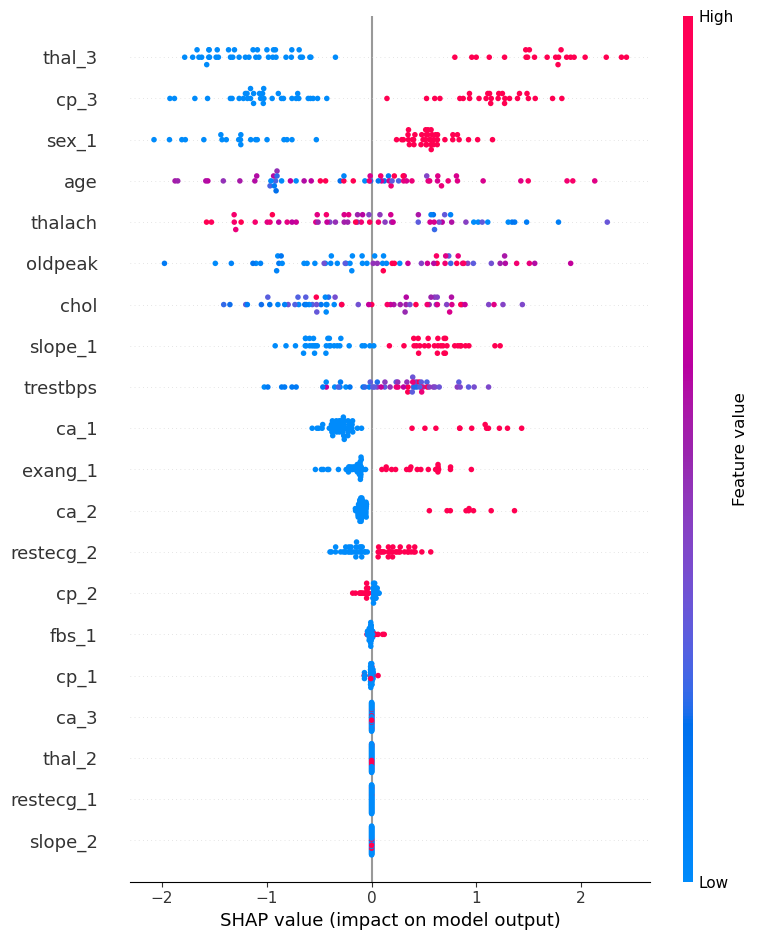

In [211]:
# Create SHAP TreeExplainer for the trained XGBoost model
explainer = shap.TreeExplainer(XGBoost)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# For binary classification with shape (samples, features, classes)
if shap_values.ndim == 3:
    shap_values_pos_class = shap_values[:, :, 1]
else:
    shap_values_pos_class = shap_values

# Plot the SHAP summary plot
shap.summary_plot(shap_values_pos_class, X_test)

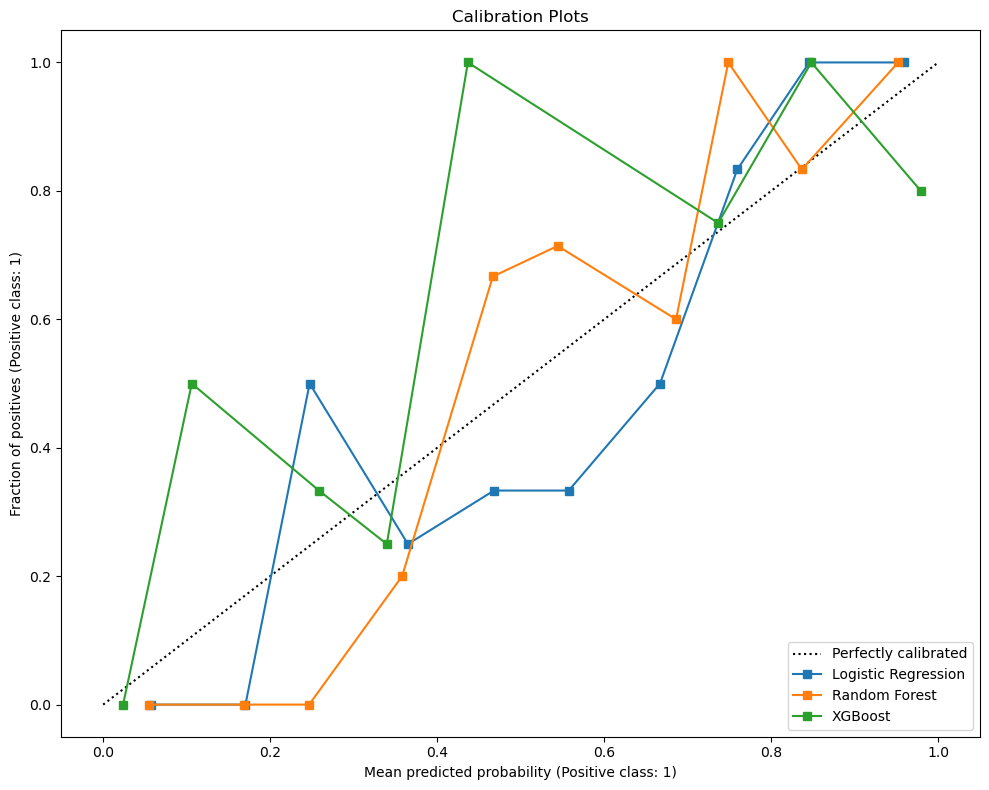

In [225]:

# Get predicted probabilities for the positive class
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]
y_prob_xg = XGBoost.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
CalibrationDisplay.from_predictions(y_test, y_prob_lr, n_bins=10, ax=ax, name="Logistic Regression")
CalibrationDisplay.from_predictions(y_test, y_prob_rf, n_bins=10, ax=ax, name="Random Forest")
CalibrationDisplay.from_predictions(y_test, y_prob_xg, n_bins=10, ax=ax, name="XGBoost")

ax.set_title("Calibration Plots")
plt.tight_layout()

plt.show()

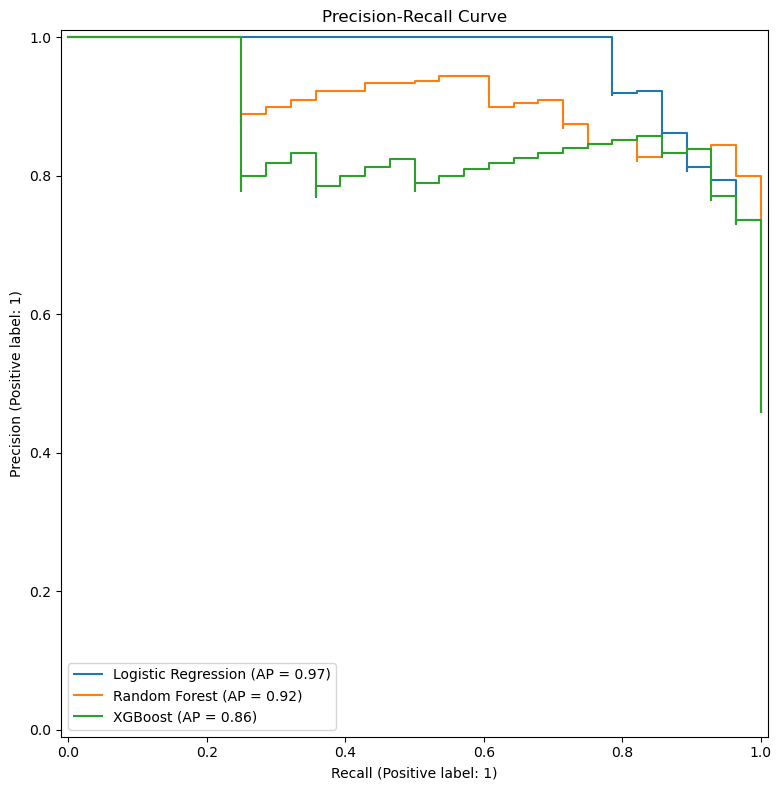

In [227]:
fig, ax = plt.subplots(figsize=(10, 8))
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, ax=ax, name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(random_forest, X_test, y_test, ax=ax, name="Random Forest")
PrecisionRecallDisplay.from_estimator(XGBoost, X_test, y_test, ax=ax, name="XGBoost")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [231]:

# --- Fairness Analysis ---
# 1. Split the test data by sex
# The one-hot encoded 'sex' feature has a column 'sex_1' where 1 is male and 0 is female.
male_mask = X_test['sex_1'] == 1
female_mask = X_test['sex_1'] == 0

# Get the data for each subgroup
X_test_male = X_test[male_mask]
y_test_male = y_test[male_mask]

X_test_female = X_test[female_mask]
y_test_female = y_test[female_mask]

# 2. Evaluate the Random Forest model on each subgroup
y_pred_male = random_forest.predict(X_test_male)
y_pred_female = random_forest.predict(X_test_female)

# 3. Print performance metrics for each subgroup
print("--- Random Forest Performance (Male Subgroup) ---")
print(f"Accuracy: {accuracy_score(y_test_male, y_pred_male):.3f}")
print(f"Precision: {precision_score(y_test_male, y_pred_male):.3f}")
print(f"Recall: {recall_score(y_test_male, y_pred_male):.3f}")
print(f"F1 Score: {f1_score(y_test_male, y_pred_male):.3f}")
print("\n")

print("--- Random Forest Performance (Female Subgroup) ---")
print(f"Accuracy: {accuracy_score(y_test_female, y_pred_female):.3f}")
print(f"Precision: {precision_score(y_test_female, y_pred_female):.3f}")
print(f"Recall: {recall_score(y_test_female, y_pred_female):.3f}")
print(f"F1 Score: {f1_score(y_test_female, y_pred_female):.3f}")

--- Random Forest Performance (Male Subgroup) ---
Accuracy: 0.829
Precision: 0.792
Recall: 0.905
F1 Score: 0.844


--- Random Forest Performance (Female Subgroup) ---
Accuracy: 0.950
Precision: 1.000
Recall: 0.857
F1 Score: 0.923
